This include the Stage 3 MBdeconv training by using the validation dataset (valid_dataloader) and were generated by the 05C scripts.

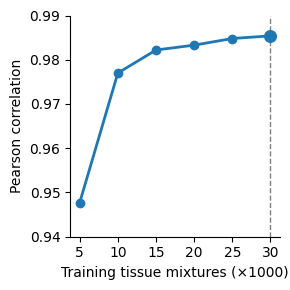

In [5]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

sat = pd.DataFrame({
    "Training": [5000,10000,15000,20000,25000,30000],
    "Pearson": [0.9477,0.9770,0.9822,0.9833,0.9848,0.9854]
})

fig, ax = plt.subplots(figsize=(3,3))

ax.plot(
    sat["Training"]/1000,
    sat["Pearson"],
    marker="o",
    linewidth=2,
    markersize=6
)

selected = sat.loc[sat["Training"]==30000].iloc[0]

ax.axvline(
    x=30,
    linestyle="--",
    linewidth=1,
    color="0.5"
)

ax.scatter(
    30,
    selected["Pearson"],
    s=70,
    zorder=3
)

ax.set_xlabel("Training tissue mixtures (×1000)")
ax.set_ylabel("Pearson correlation")

ax.set_xticks([5,10,15,20,25,30])
ax.set_ylim(0.94,0.99)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    "DECODE_GTEx_TOO_training_saturation_Stage3Val.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight"
)

plt.show()

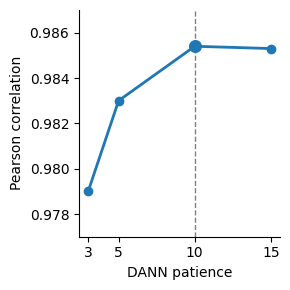

In [3]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

dann = pd.DataFrame({
    "Patience": [3, 5, 10, 15],
    "Epochs": [118, 153, 203, 208],
    "Pearson": [0.9790, 0.9830, 0.9854, 0.9853]
})

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(
    dann["Patience"],
    dann["Pearson"],
    marker="o",
    linewidth=2,
    markersize=6
)

selected = dann.loc[dann["Patience"] == 10].iloc[0]

ax.axvline(
    x=10,
    linestyle="--",
    linewidth=1,
    color="0.5"
)

ax.scatter(
    selected["Patience"],
    selected["Pearson"],
    s=70,
    zorder=3
)


ax.set_xlabel("DANN patience")
ax.set_ylabel("Pearson correlation")

ax.set_xticks([3,5,10,15])
ax.set_ylim(0.977,0.987)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    "DECODE_GTEx_TOO_DANN_patience_Stage3Val.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight"
)

plt.show()

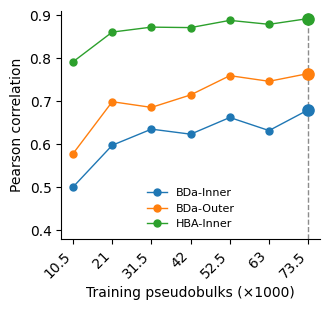

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

sat = pd.DataFrame({
    "Training": [
        10.5, 21.0, 31.5, 42.0, 52.5, 63.0, 73.5
    ],
    "BDa-Inner": [
        0.5009, 0.5979, 0.6353, 0.6236,
        0.6624, 0.6320, 0.6801
    ],
    "BDa-Outer": [
        0.5784, 0.6990, 0.6858, 0.7148,
        0.7595, 0.7464, 0.7644
    ],
    "HBA-Inner": [
        0.7917, 0.8607, 0.8722, 0.8711,
        0.8879, 0.8787, 0.8921
    ]
})

selected_training = {
    "BDa-Inner": 73.5,
    "BDa-Outer": 73.5,
    "HBA-Inner": 73.5
}

fig, ax = plt.subplots(figsize=(3.4, 3.2))

lines = {}

for reference in ["BDa-Inner", "BDa-Outer", "HBA-Inner"]:
    line, = ax.plot(
        sat["Training"],
        sat[reference],
        marker="o",
        linewidth=1,
        markersize=5,
        label=reference
    )
    lines[reference] = line

    selected_x = selected_training[reference]
    selected_y = sat.loc[
        sat["Training"] == selected_x,
        reference
    ].iloc[0]

    # Larger marker for the selected model
    ax.scatter(
        selected_x,
        selected_y,
        s=65,
        color=line.get_color(),
        zorder=4
    )

# Vertical lines at the selected training sizes
for selected_x in sorted(set(selected_training.values())):
    ax.axvline(
        selected_x,
        linestyle="--",
        linewidth=1,
        color="0.55",
        zorder=0
    )

ax.set_xlabel("Training pseudobulks (×1000)")
ax.set_ylabel("Pearson correlation")

ax.set_xticks(sat["Training"])
ax.set_xticklabels(
    ["10.5", "21", "31.5", "42", "52.5", "63", "73.5"],
    rotation=45,
    ha="right"
)

ax.set_ylim(0.38, 0.91)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out")

ax.legend(
    frameon=False,
    fontsize=8,
    handlelength=1.8
)

fig.tight_layout()

fig.savefig(
    "DECODE_COO_training_saturation_Stage3Val.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight"
)

plt.show()

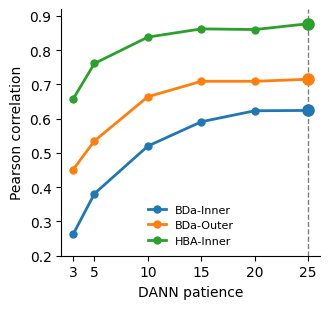

In [6]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

dann = pd.DataFrame({
    "Patience": [3, 5, 10, 15, 20, 25],

    "BDa-Inner": [
        0.262,
        0.381,
        0.520,
        0.591,
        0.623,
        0.624
    ],

    "BDa-Outer": [
        0.451,
        0.535,
        0.664,
        0.709,
        0.709,
        0.715
    ],

    "HBA-Inner": [
        0.657,
        0.761,
        0.838,
        0.862,
        0.860,
        0.877
    ]
})

selected_patience = 25

fig, ax = plt.subplots(figsize=(3.4, 3.2))

for reference in ["BDa-Inner", "BDa-Outer", "HBA-Inner"]:

    line, = ax.plot(
        dann["Patience"],
        dann[reference],
        marker="o",
        linewidth=2,
        markersize=5,
        label=reference
    )

    selected_y = dann.loc[
        dann["Patience"] == selected_patience,
        reference
    ].iloc[0]

    ax.scatter(
        selected_patience,
        selected_y,
        s=65,
        color=line.get_color(),
        zorder=4
    )

ax.axvline(
    selected_patience,
    linestyle="--",
    linewidth=1,
    color="0.5"
)

ax.set_xlabel("DANN patience")
ax.set_ylabel("Pearson correlation")

ax.set_xticks([3, 5, 10, 15, 20, 25])
ax.set_ylim(0.2, 0.92)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out")

ax.legend(
    frameon=False,
    fontsize=8,
    handlelength=1.6
)

fig.tight_layout()

fig.savefig(
    "DECODE_COO_DANN_patience_Stage3Val.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight"
)

plt.show()